In [1]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys #首先，添加路径，windows的路径和linux的路径符号不同\\,/,注意区别  #r是为了告诉python这是路径，别#把\n等特殊组合给转译）
sys.path.append(r"./main_code")
import generate_data3,grid_cell,adaptive_int_fix,visual,cal_S_grad,org_m,mea_3D,net_3D_fix,S_valgrad,error_general_3D,main_fix
CUDA_LAUNCH_BLOCKING=1

def ana_S(x, center,R, r, S0):
    x1=x[:,0]
    x2=x[:,1]
    x3=x[:,2]
    cx, cy, cz = center[0,0],center[0,1],center[0,2]
    
    # 计算每个点相对于偏移中心是否在环形内部的条件a
    
    x_rel, y_rel, z_rel = x1 - cx, x2 - cy, x3 - cz
    condition = (np.sqrt(x_rel**2 + y_rel**2) - R)**2 + z_rel**2 <= r**2
    
    # 使用 np.where 根据条件返回 S0 或 0
    return np.where(condition, S0, 0.0)

cuda:1


In [ ]:
import copy
Nx,Ny,Nz=1,1,1
Ix,Iy,Iz=4,4,4  #x方向网格点
nx,ny,nz=3,3,3  #每个网格x方向的高斯点
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81]
R_true = 0.25            # 主半径 R
r_true = 0.15            # 次半径 r
S0= 1.0  
tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max=-0.5,0.5,-0.5,0.5,-0.5,0.5
b_x_min,b_x_max,b_y_min,b_y_max,b_z_min,b_z_max=-0.75,0.75,-0.75,0.75,-0.75,0.75 #边界gamma处
num_batches_gauss=1
b_n=10
points_b=mea_3D.generate_cube_surface(b_x_min,b_x_max,b_y_min,b_y_max,b_z_min,b_z_max,b_n) #在边界Γ处收集数据
center_true=np.array([[0.0,0.0,0.0]])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
cupy_device=1
num_batches_gauss=4
num_batches_appr=10
num_batches_mea=1

In [ ]:
F_diri_5=np.load("./noise=5%/F_diri_5%.npy")


In [20]:
M=3600
af="Tanh"   #先用tanh
R_m=20
models0 = net_3D_fix.local_rep(in_features=3, out_features=1, hidden_layers=1, M=M, x_max=tau_x_min, x_min=tau_x_max, y_max=tau_y_max, y_min=tau_y_min,z_min=tau_z_min,z_max=tau_z_max, r_min=[], r_max=[],R_min=[],R_max=[],b1_min=[],b1_max=[],b2_min=[],b2_max=[],b3_min=[],b3_max=[],K_min=[],K_max=[],R_m_for_init=R_m,af=af,Shape=[],device=device).to(device)

Plotting 64 cells. Levels: 0 to 0


/mnt/store/hxw-y23/3D/环形/自适应/../main_code2/main_fix.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


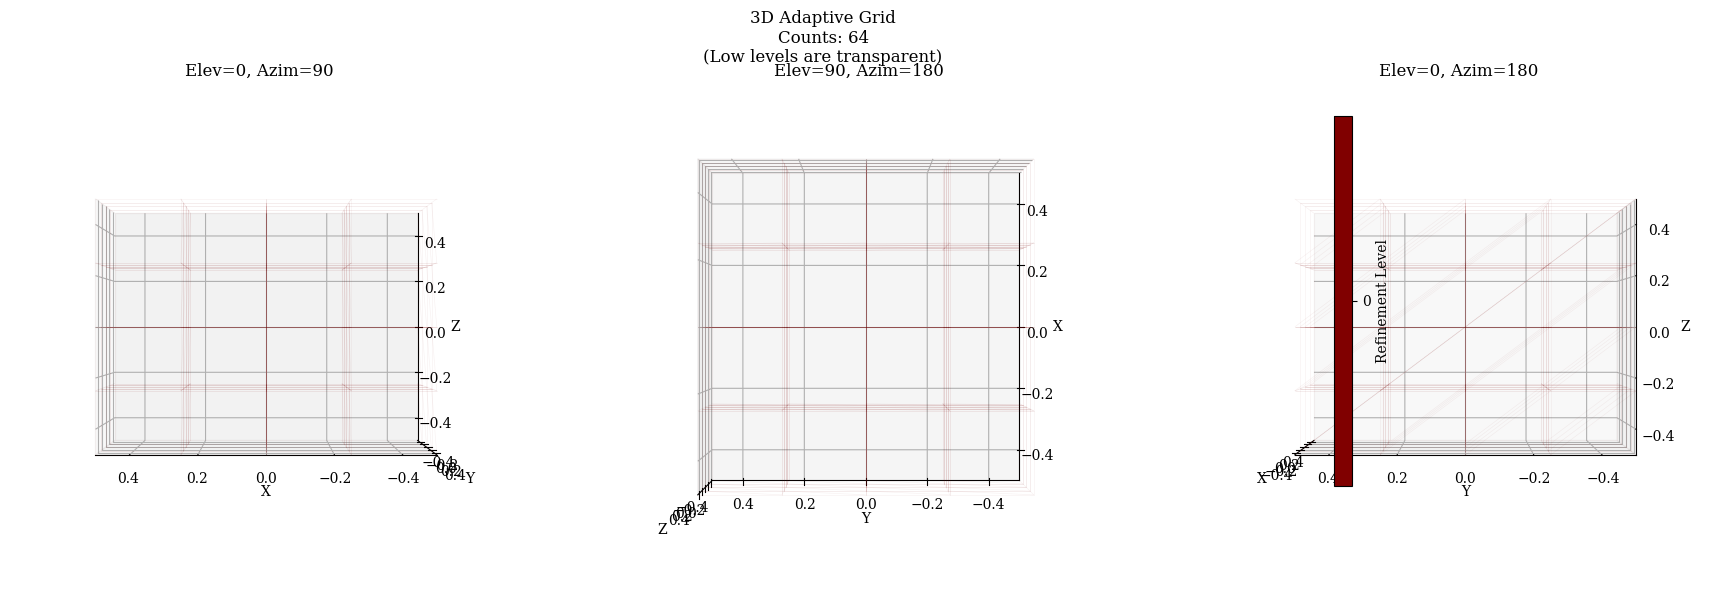

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


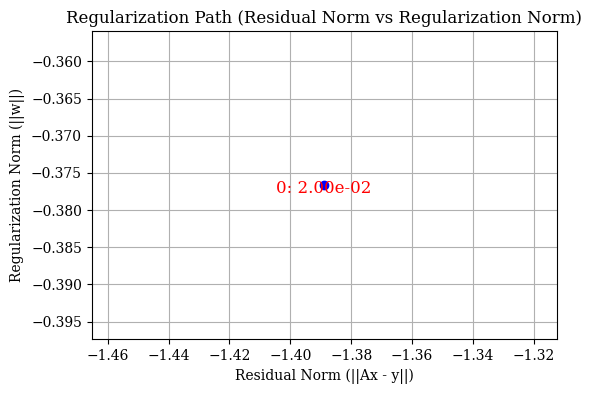

第 0 次迭代的train误差：
S_l_inf= 1.886297133460697 S_L_2= 0.14651663159500478 S_l_2= 0.3998662983501986
第 0 次迭代的泛化误差：


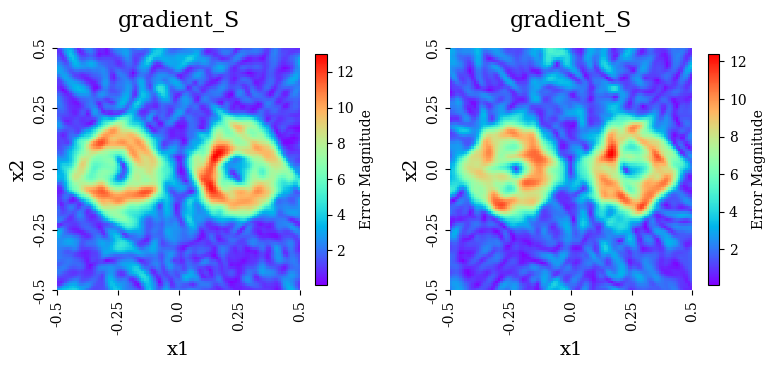

S_l_inf= 2.2947695017749514 S_L_2= 0.14011542015259656 S_l_2= 0.4281904045868159


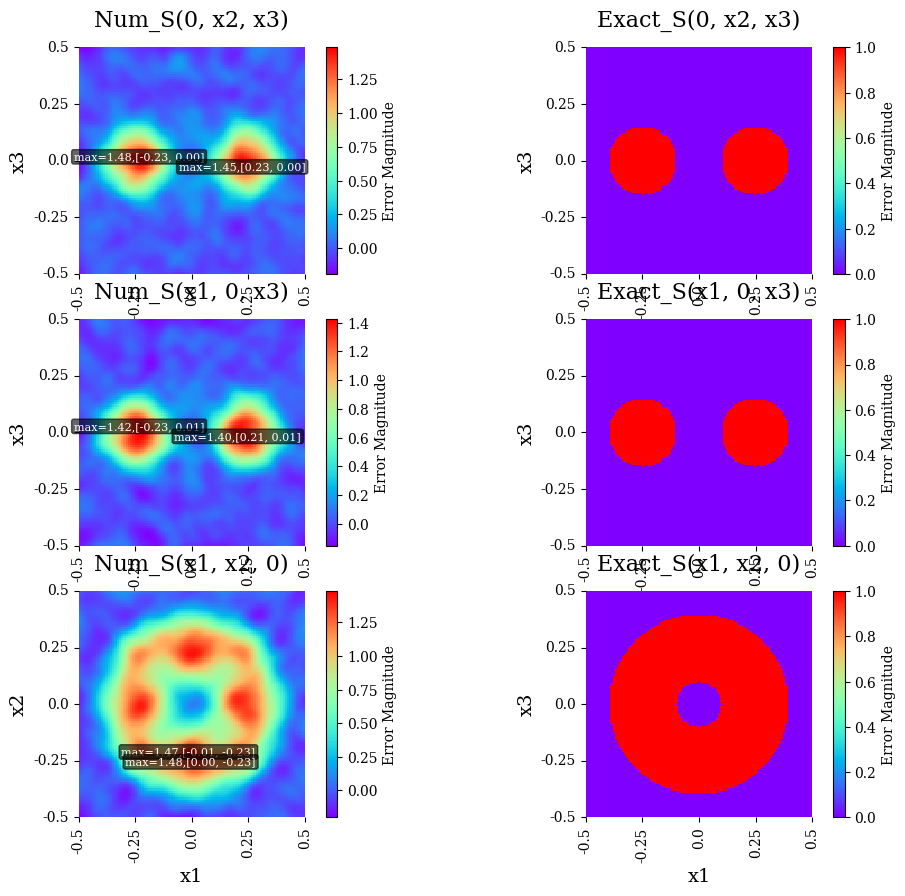

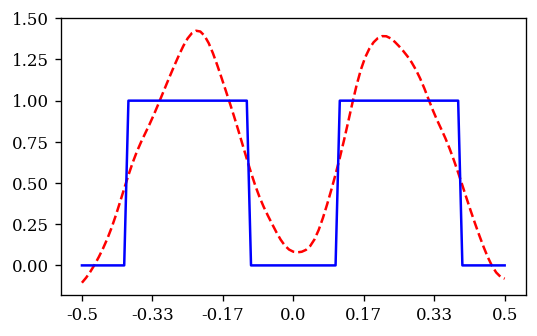

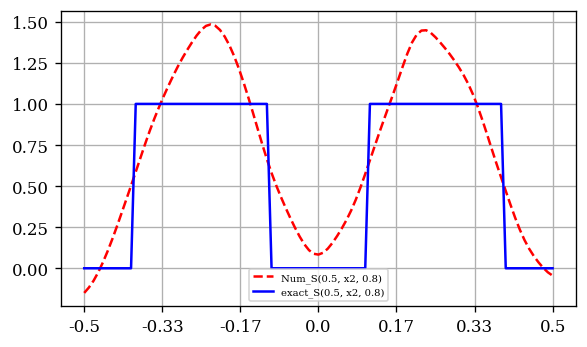

S_l_inf= 1.886297133460697 S_L_2= 0.14651663159500478 S_l_2= 0.3998662983501986
S_l_inf= 2.1495980671345736 S_L_2= 0.14745418218842046 S_l_2= 0.43560852328106026
当前总网格数目: 512
Visualization failed: name 'MeshVisualizer' is not defined
Plotting 512 cells. Levels: 1 to 1


/mnt/store/hxw-y23/3D/环形/自适应/../main_code2/main_fix.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


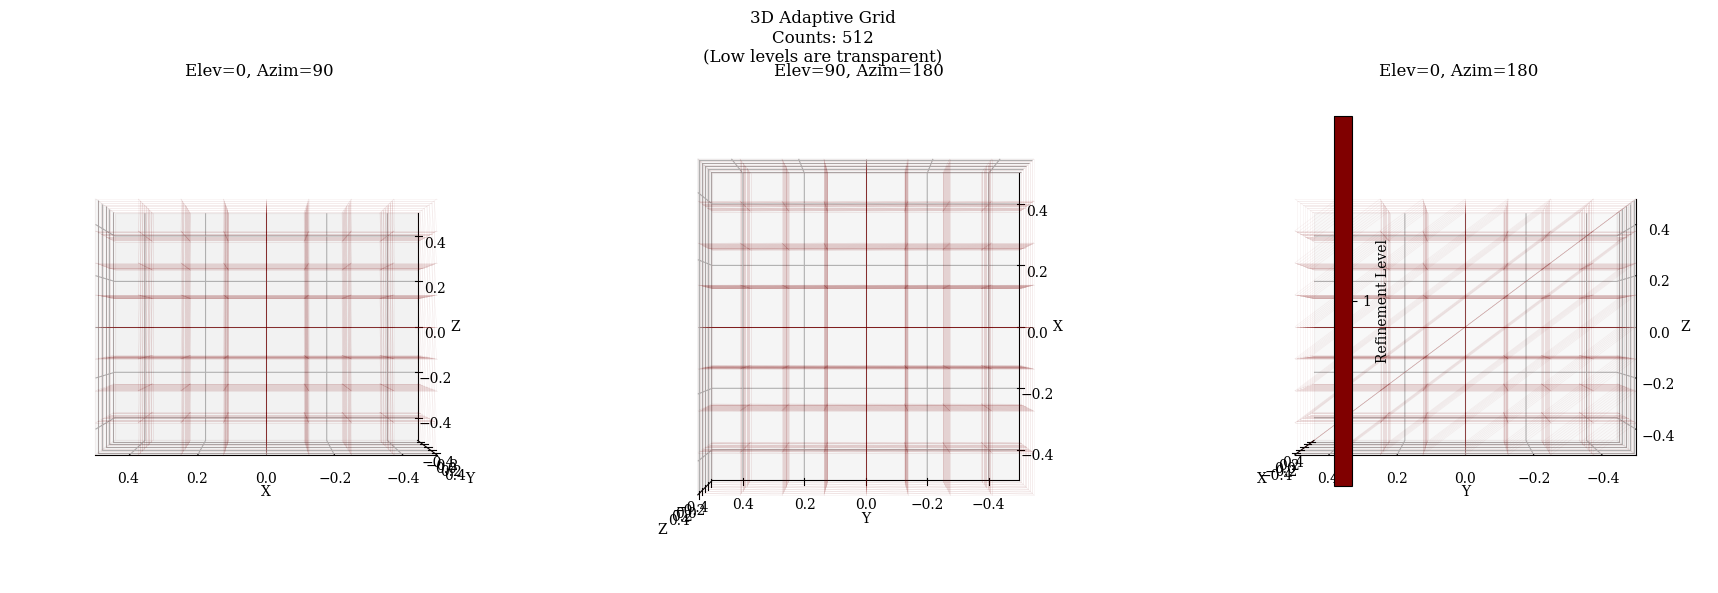

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


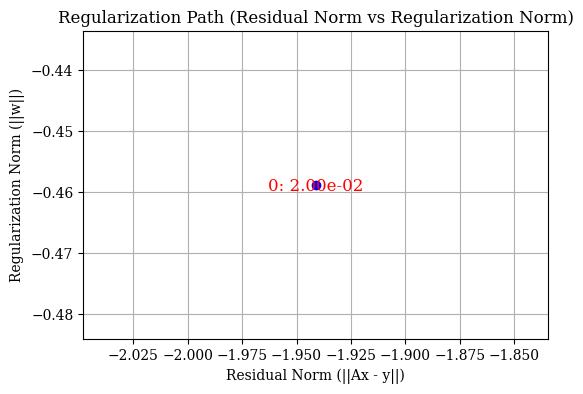

第 1 次迭代的train误差：
S_l_inf= 1.8266321927259062 S_L_2= 0.12087764664804963 S_l_2= 0.3570962340475529
第 1 次迭代的泛化误差：


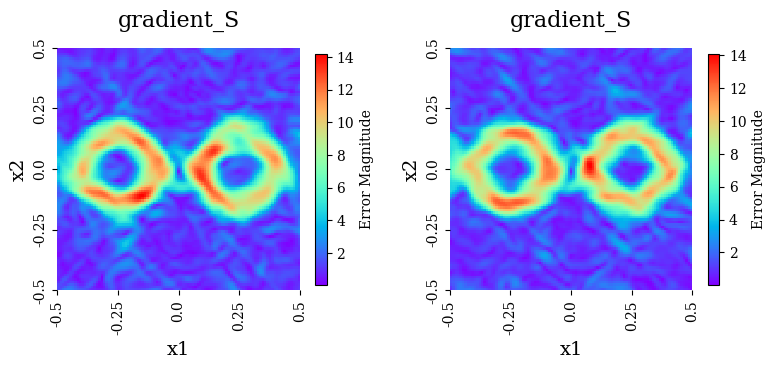

S_l_inf= 2.039669930300307 S_L_2= 0.11710114795747216 S_l_2= 0.35785916972509174


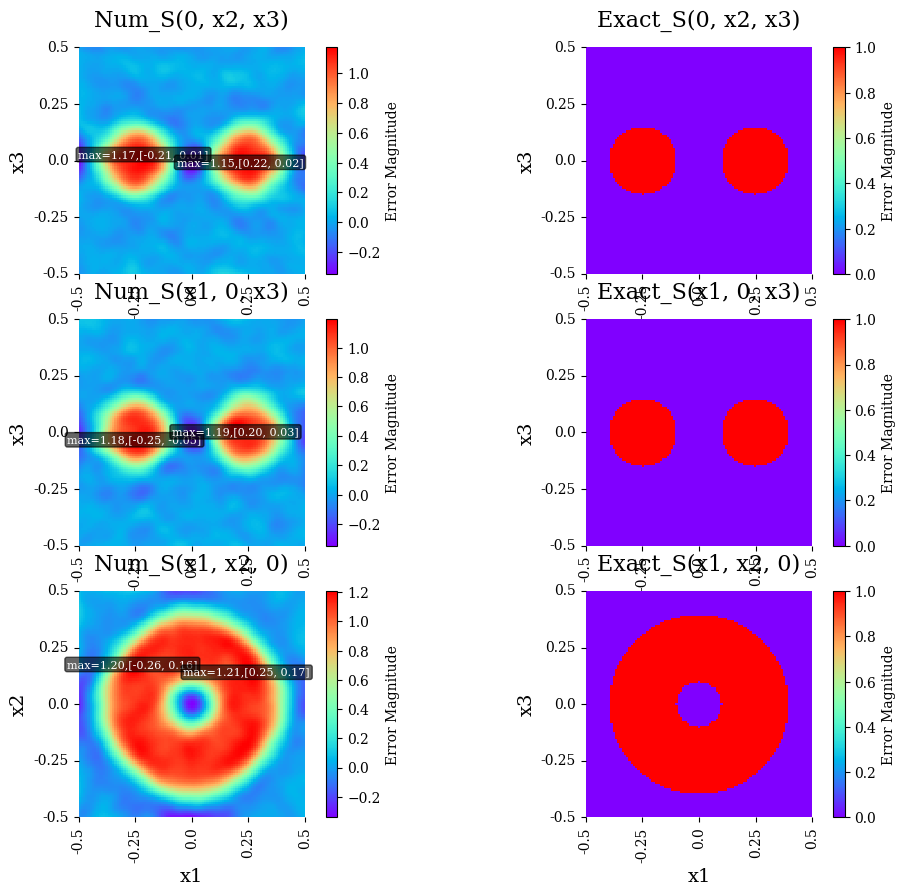

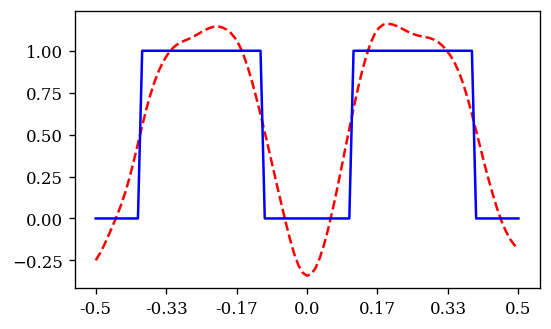

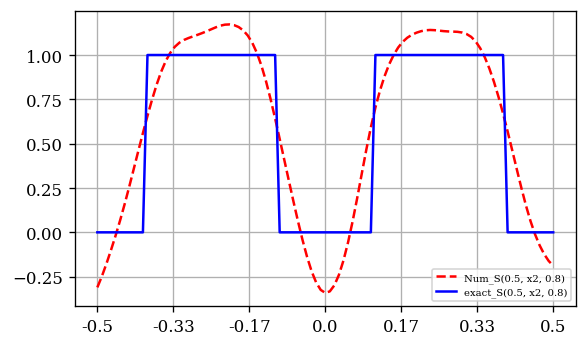

S_l_inf= 1.8266321927259062 S_L_2= 0.12087764664804963 S_l_2= 0.3570962340475529
S_l_inf= 1.9539871964975144 S_L_2= 0.11798944099737316 S_l_2= 0.3539683229921195
当前总网格数目: 1660
Visualization failed: name 'MeshVisualizer' is not defined
Plotting 1660 cells. Levels: 1 to 2


/mnt/store/hxw-y23/3D/环形/自适应/../main_code2/main_fix.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


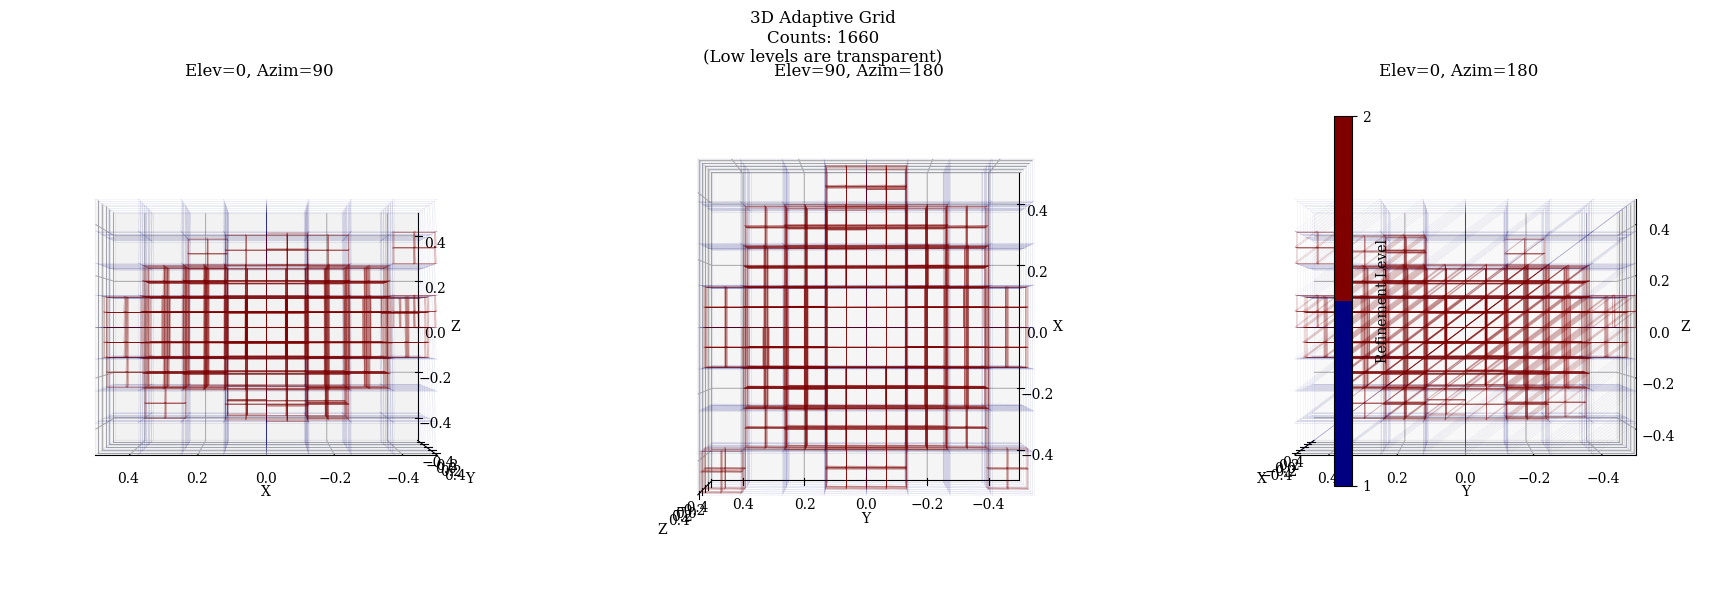

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


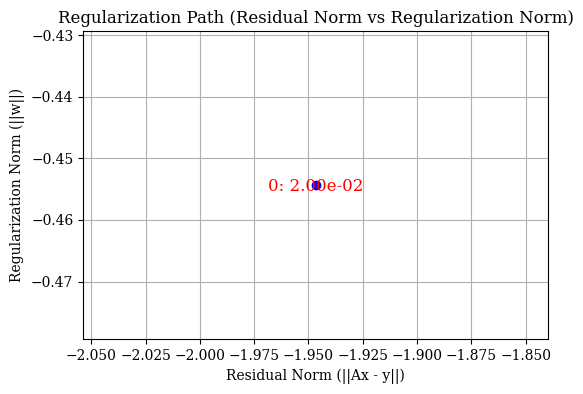

第 2 次迭代的train误差：
S_l_inf= 1.2436903030349087 S_L_2= 0.17956823321246598 S_l_2= 0.3429452834593453
第 2 次迭代的泛化误差：


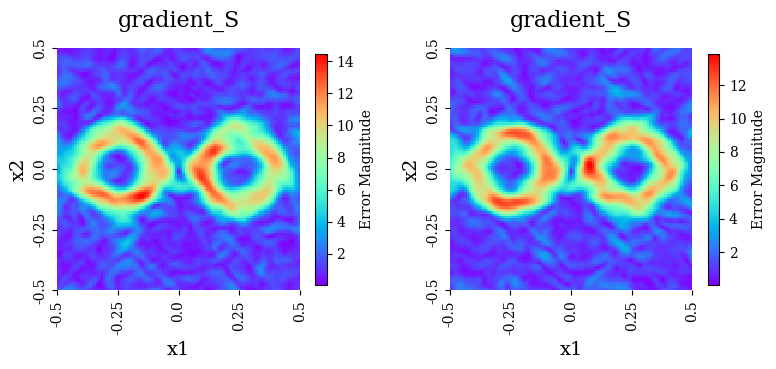

S_l_inf= 2.0370230501711424 S_L_2= 0.11662771465871896 S_l_2= 0.3564123654010764


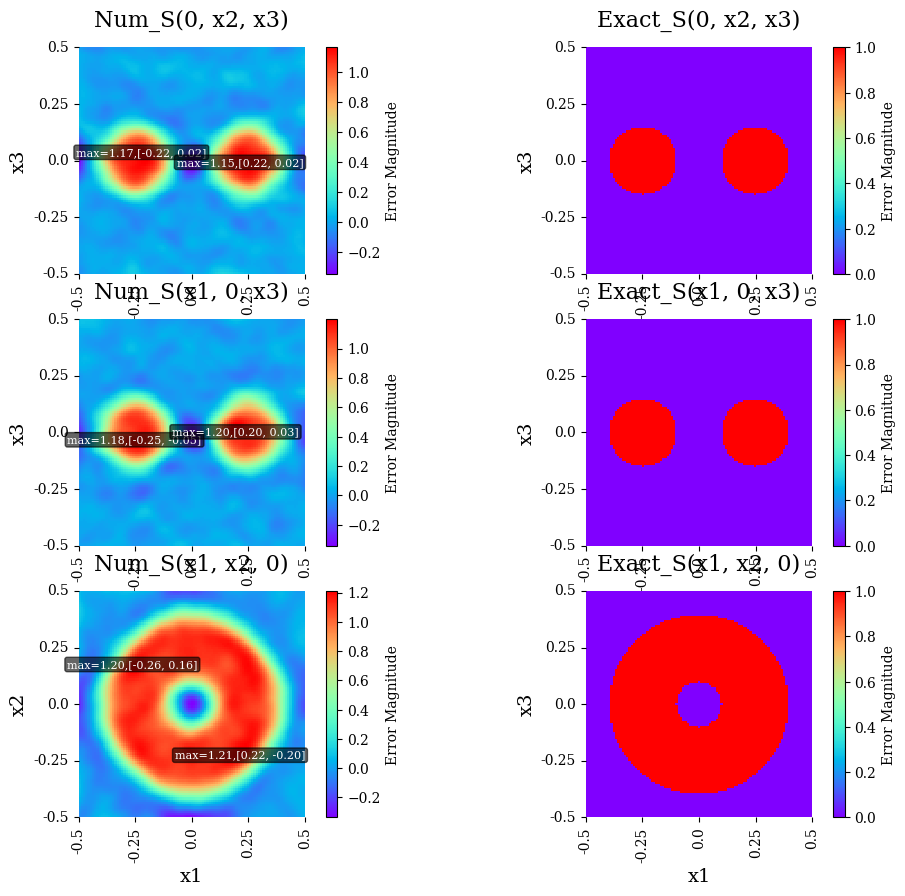

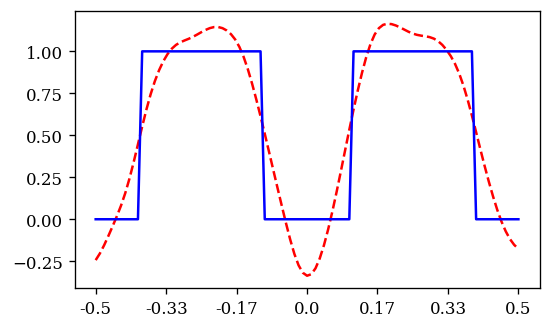

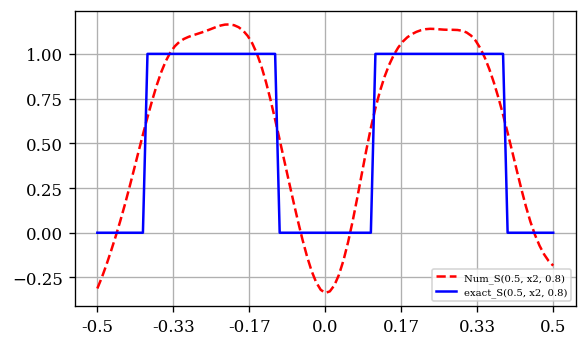

S_l_inf= 1.2436903030349087 S_L_2= 0.17956823321246598 S_l_2= 0.3429452834593453
S_l_inf= 1.2671955391426093 S_L_2= 0.1800660472293668 S_l_2= 0.3448233109232504
当前总网格数目: 5006
Visualization failed: name 'MeshVisualizer' is not defined


In [22]:
Ix,Iy,Iz=4,4,4  #x方向网格点
nx,ny,nz=3,3,3  #每个网格x方向的高斯点
ratio1=[0.5,0.5,0.5]
cells= grid_cell.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max,Ix,nx,points_b) #创造初始网格
initial_cells=copy.deepcopy(cells) #copy一份
delta=10**(-3)

lamb_regu=2*np.logspace(-2,-1,1)
Qx,Qy,Qz=50,50,50
iter_int=3
max_level=4
current_maxiter=1
#refine_threshold_S=[1e-4, 5e-4, 1e-3, 5e-3, 1e-2] #刚开始阈值小多细分，后面阈值大少细分
refine_threshold_S=[1e-5, 5e-5, 1e-4, 5e-4, 1e-3]#刚开始阈值小多细分，后面阈值大少细分
#refine_threshold_grad=[1e-7, 1e-7, 8e-7, 8e-7, 8e-7] #刚开始阈值小多细分，后面阈值大少细分
#refine_threshold_grad=[1e-8, 1e-8, 1e-7, 1e-7, 1e-6] #刚开始阈值小多细分，后面阈值大少细分
refine_threshold_grad=[5e-9, 1e-8, 5e-8, 1e-7, 5e-7]
refine_threshold_noise=[1e-2,1e-2,1e-2,1e-2,1e-2,1e-2]
condition="Dirichlet"
cells_store,refinement_stats_store,w_,point_number,g_store,g_S,S_num_store,S_l2,S_basis_store=main_fix.ada_int(iter_int,delta,cells,nx,models0,M,af,kk,F_diri_5,tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max,center_true,R_true,r_true,S0,ana_S,points_b,lamb_regu,Qx,Qy,Qz,ratio1,condition,device,cupy_device,refine_threshold_S,refine_threshold_grad,refine_threshold_noise,current_maxiter,max_level)

In [ ]:
import pickle
output_pickle_file = "./noise=5%/cells_store.pkl"
with open(output_pickle_file, 'wb') as f: # 'wb' for write binary
    pickle.dump(cells_store,f)

In [ ]:
np.save("./noise=5%/S_basis_store.npy",S_basis_store[-1])
np.save("./noise=5%/g_S.npy",g_S)

Grid shape from g_S: 101x101x101
Number of detected clusters: 1
Cluster 0: L=(0.82, 0.82, 0.33), AR=2.48
  Res_Box=0.251 vs Res_Ellip=0.193
  -> Decision: SphericalShell
  CV of S_num: 0.260
    Rect Residual: 0.2507, Ellip Residual: 0.1933
    Aspect Ratio: 2.485
    Curvature - Std: 0.0303, Mean: 0.0886, Peak Ratio: 1.87


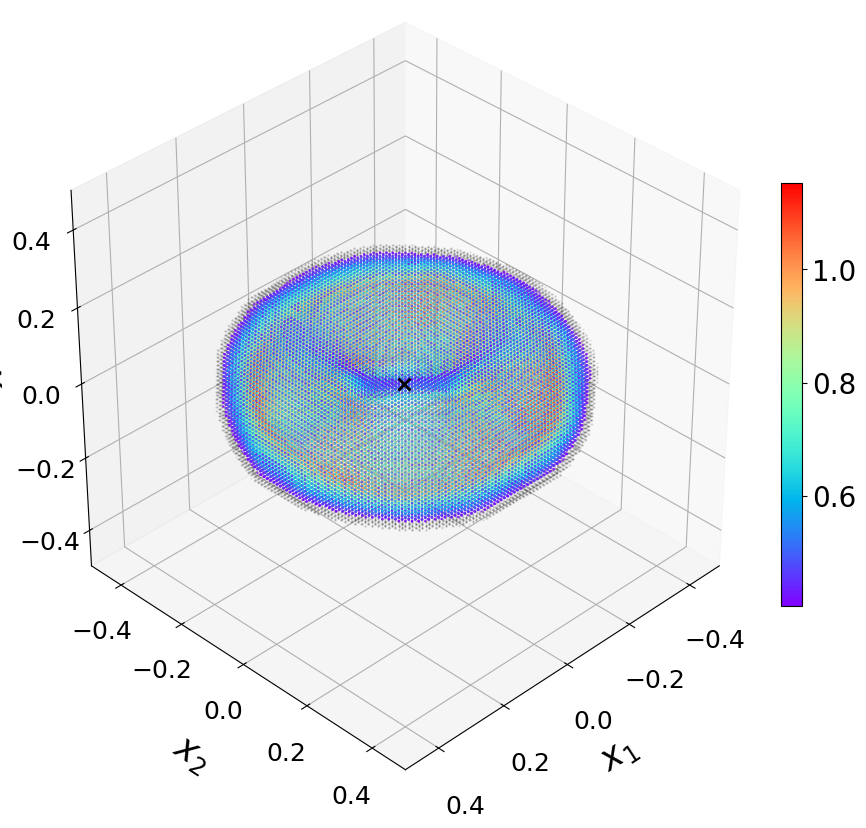

In [7]:
from importlib import reload
import Bound_detect3D
reload(Bound_detect3D)

# 动态获取 g_S 的形状，确保维度匹配
nx, ny, nz = g_S.shape
print(f"Grid shape from g_S: {nx}x{ny}x{nz}")

x = np.linspace(tau_x_min, tau_x_max, nx)
y = np.linspace(tau_y_min, tau_y_max, ny)
z = np.linspace(tau_z_min, tau_z_max, nz)

# 关键：使用 indexing='ij' 以匹配矩阵索引 (row, col, depth) -> (x, y, z)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

eps_cluster=0.02
mini_samples=20 
para_abs=3
para_grad=3
elev=35
azim=45
results = Bound_detect3D.detect_shape_3d(
    g_S, X, Y, Z, 
    tau_x_min, tau_x_max, tau_y_min, tau_y_max, tau_z_min, tau_z_max,
    para_abs, para_grad, eps_cluster, mini_samples, 
    S_num_store[-1], elev=elev, azim=azim,
    output_directory="./noise=5%", 
    output_filename="plot_3d_top1.png"
)

Grid shape from g_S: 101x101x101
Number of detected clusters: 1
Cluster 0: L=(0.82, 0.82, 0.33), AR=2.48
  Res_Box=0.251 vs Res_Ellip=0.193
  -> Decision: SphericalShell
  CV of S_num: 0.260
    Rect Residual: 0.2507, Ellip Residual: 0.1933
    Aspect Ratio: 2.485
    Curvature - Std: 0.0303, Mean: 0.0886, Peak Ratio: 1.87


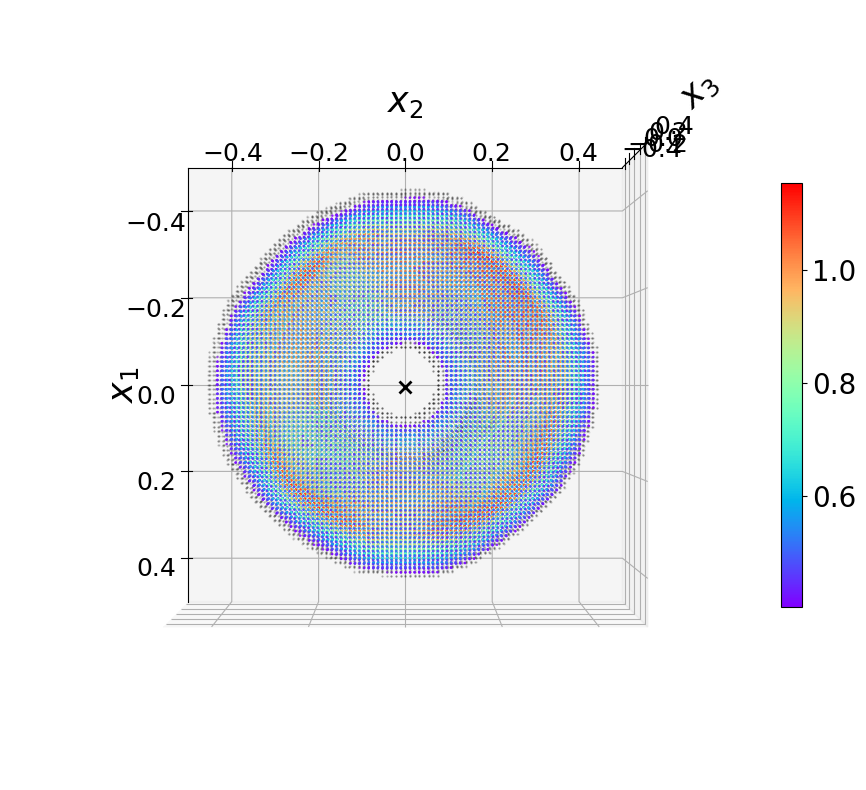

In [6]:
from importlib import reload
import Bound_detect3D
reload(Bound_detect3D)

# 动态获取 g_S 的形状，确保维度匹配
nx, ny, nz = g_S.shape
print(f"Grid shape from g_S: {nx}x{ny}x{nz}")

x = np.linspace(tau_x_min, tau_x_max, nx)
y = np.linspace(tau_y_min, tau_y_max, ny)
z = np.linspace(tau_z_min, tau_z_max, nz)

# 关键：使用 indexing='ij' 以匹配矩阵索引 (row, col, depth) -> (x, y, z)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

eps_cluster=0.02
mini_samples=20 
para_abs=3
para_grad=3
elev=90
azim=0
results = Bound_detect3D.detect_shape_3d(
    g_S, X, Y, Z, 
    tau_x_min, tau_x_max, tau_y_min, tau_y_max, tau_z_min, tau_z_max,
    para_abs, para_grad, eps_cluster, mini_samples, 
    S_num_store[-1], elev=elev, azim=azim,
    output_directory="./noise=5%", 
    output_filename="plot_3d_top1.png"
)

Grid shape from g_S: 101x101x101
Number of detected clusters: 1
Cluster 0: L=(0.82, 0.82, 0.33), AR=2.48
  Res_Box=0.251 vs Res_Ellip=0.193
  -> Decision: SphericalShell
  CV of S_num: 0.260
    Rect Residual: 0.2507, Ellip Residual: 0.1933
    Aspect Ratio: 2.485
    Curvature - Std: 0.0303, Mean: 0.0886, Peak Ratio: 1.87


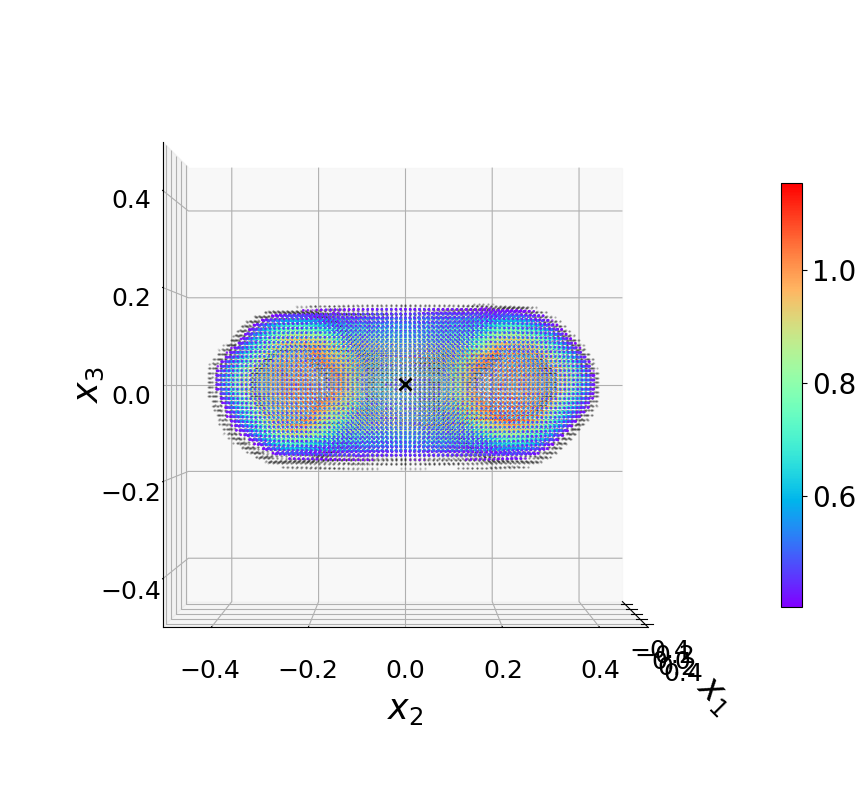

In [8]:
from importlib import reload
import Bound_detect3D
reload(Bound_detect3D)

# 动态获取 g_S 的形状，确保维度匹配
nx, ny, nz = g_S.shape
print(f"Grid shape from g_S: {nx}x{ny}x{nz}")

x = np.linspace(tau_x_min, tau_x_max, nx)
y = np.linspace(tau_y_min, tau_y_max, ny)
z = np.linspace(tau_z_min, tau_z_max, nz)

# 关键：使用 indexing='ij' 以匹配矩阵索引 (row, col, depth) -> (x, y, z)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

eps_cluster=0.02
mini_samples=20 
para_abs=3
para_grad=3
elev=0
azim=0
results = Bound_detect3D.detect_shape_3d(
    g_S, X, Y, Z, 
    tau_x_min, tau_x_max, tau_y_min, tau_y_max, tau_z_min, tau_z_max,
    para_abs, para_grad, eps_cluster, mini_samples, 
    S_num_store[-1], elev=elev, azim=azim,
    output_directory="./noise=5%", 
    output_filename="plot_3d_top1.png"
)

In [9]:
results

[{'cluster_id': 0,
  'shape': 'SphericalShell',
  'params': {'center': array([ 0.00416614, -0.00017789,  0.00138089]),
   'R_outer': 0.3917281770137053,
   'R_inner': 0.14049967859179802,
   'r': 0.33},
  'profile': 'Sigmoid'}]

In [54]:
center=results[0]['params']['center']
r_inner1=(results[0]['params']['R_outer']-results[0]['params']['R_inner'])/2
r_inner2=results[0]['params']['r']/2
r_inner=(r_inner1+r_inner2)/2
R=results[0]['params']['R_outer']-r_inner

In [55]:
r_inner

0.14530712460547685

In [67]:
R

0.24642105240822848

In [56]:
M=1600
eps_r=0.05
eps_R=0.05
eps_c=0.05
r_min,r_max=(1-eps_r)*r_inner,(1+eps_r)*r_inner
R_min,R_max=(1-eps_R)*R,(1+eps_R)*R
b1_min,b1_max=-center[0]*(1+eps_c),center[0]*(1+eps_c)
b2_min,b2_max=center[1]*(1+eps_c),-center[1]*(1+eps_c)
b3_min,b3_max=-center[2]*(1+eps_c),center[2]*(1+eps_c)

K_min,K_max=2000,50000
condition="Dirichlet"
af="sigmoid"
Shape="sweet"
R_m=20
model_sigmoid=net_3D_fix.local_rep(in_features=3, out_features=1, hidden_layers=1, M=M, x_min=tau_x_min, x_max=tau_x_max, y_min=tau_y_min, y_max=tau_y_max,z_min=tau_z_min,z_max=tau_z_max,r_min=r_min,r_max=r_max,R_min=R_min,R_max=R_max,b1_min=b1_min,b1_max=b1_max,b2_min=b2_min,b2_max=b2_max,b3_min=b3_min,b3_max=b3_max,K_min=K_min,K_max=K_max,R_m_for_init=R_m,af=af,Shape=Shape,device=device).to(device)

In [58]:
len(cells_store[-1])

1660

In [60]:
sum_mat,all_g_p1,all_g_n,cells_copy1,S_basis=cal_S_grad.mat_assemble2(cells_store[-1],models0,model_sigmoid,[],S_basis_store[-1],"mix",Shape,kk,0,points_b,condition,device,cupy_device)

In [61]:
sum_mat.shape

(25200, 5200)

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


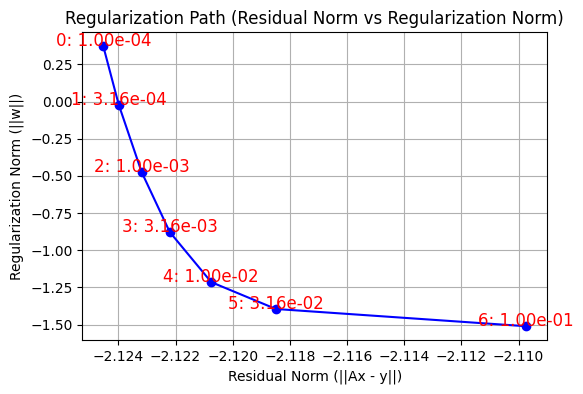

In [62]:
lamb_regu=np.logspace(-4,-1,7,endpoint=True)
res,reg_norm,w_store=org_m.L_curve(sum_mat,F_diri_5,lamb_regu,cupy_device) #先进行求解

In [ ]:
Qx,Qy,Qz=150,150,150
sample_s=error_general_3D.test_p(Qx,Qy,Qz,tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max)

lamb: 0.0009999999999999998


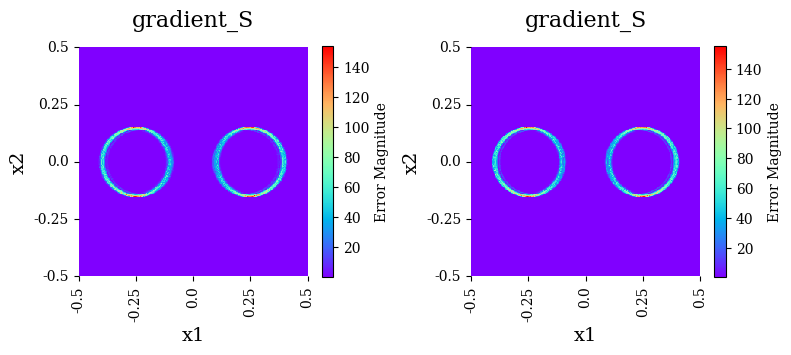

S_l_inf= 2.0001640069182356 S_L_2= 0.046898839495904635 S_l_2= 0.1415361019148476


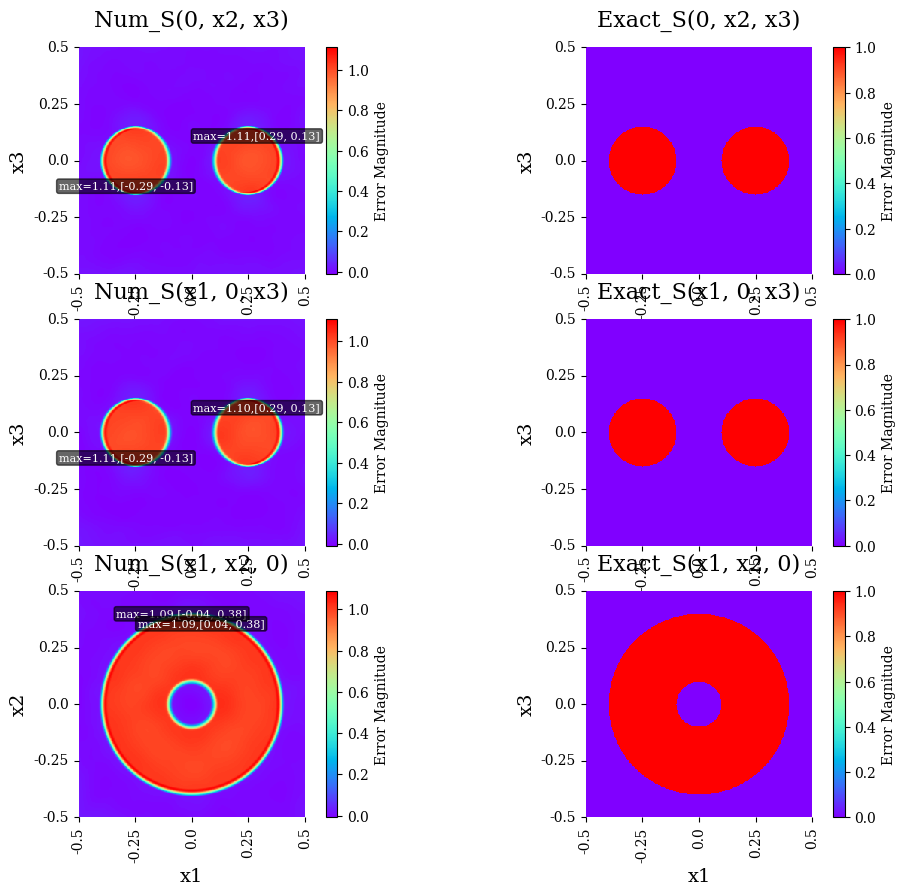

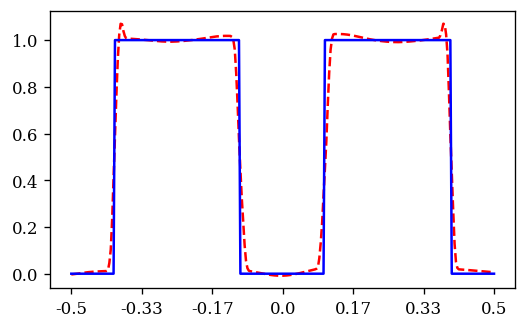

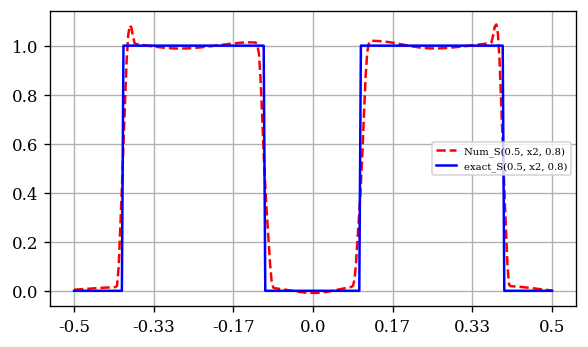

In [71]:
ratio1=[0.5,0.5,0.5]
lamb=lamb_regu[5]**2
print('lamb:',lamb)
S_num,S_true,S_l_inf,S_l_2,g_S=error_general_3D.test(models0,model_sigmoid,sample_s,w_store[:,5                                
        ],"mix","sweet",True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max,center_true,R_true,r_true,1,ana_S,1,ratio1,device)

In [ ]:
np.save("./noise=5%/w_store.npy",w_store)
np.save("./noise=5%/g_S1.npy",g_S)

In [ ]:
torch.save(models0, "./noise=5%/model_tanh_4*10**-4.pth")
torch.save(model_sigmoid, f"./noise=5%/model_sigmoid_{lamb}.pth")  

In [ ]:
np.save("./noise=5%/S_num.npy",S_num)
np.save("./noise=5%/w_store.npy",w_store)
np.save("./noise=5%/sum_mat.npy",sum_mat)

In [ ]:
n_integral=len(cells_store[-1])*27
print('n_integral:',n_integral)
print('center:',center)
print('r_inner:',r_inner)
print('R:',R)
print('lamb_regu:',lamb)
print('S_l21:',S_l_2)

n_integral: 44820
center: [ 0.00416614 -0.00017789  0.00138089]
r_inner: 0.14530712460547685
R: 0.24642105240822848
lamb_regu: 0.0009999999999999998
S_l21: 0.1415361019148476


In [76]:
len(cells_store[-1])*27

44820